In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

# import import_ipynb
from graph_functions import *
from iterative_pruning_func import *

number of graphs for n=22 : 2
[[0], [21, 1, 11], [10, 20, 2, 12], [9, 19, 3, 13], [8, 18, 4, 14], [7, 17, 5, 15], [6, 16]]


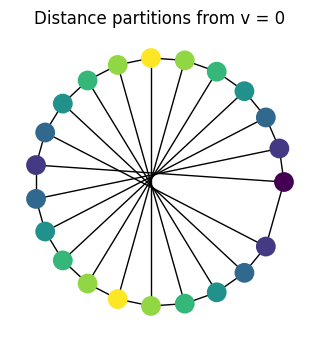

node_colors [0, 1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1]


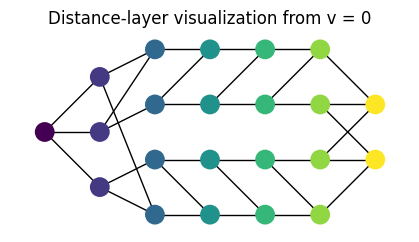

[[0], [20, 2, 11], [9, 18, 4, 13], [7, 16, 6, 15], [5, 14, 8, 17], [3, 12, 10, 19], [1, 21]]


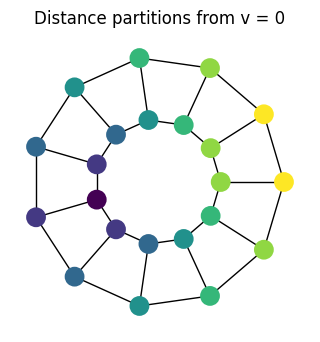

node_colors [0, 6, 1, 5, 2, 4, 3, 3, 4, 2, 5, 1, 5, 2, 4, 3, 3, 4, 2, 5, 1, 6]


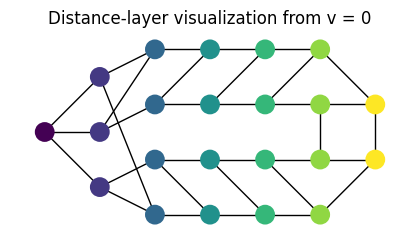

In [3]:
graphs = generate_graphs(22)

for G, _, a in graphs:
    if a == 1:
        color_distance_partitions(G, pos=mobius_pos)
    else:
        color_distance_partitions(G, pos=prism_pos)
    
    visualize_distance_partitions(G, 0, figsize=(4, 2))

number of graphs for n=22 : 2
Theoretical min infection number: 7


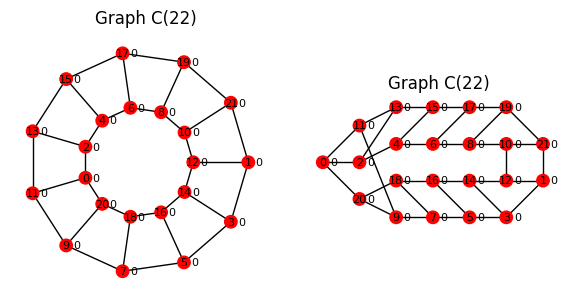

initial removal


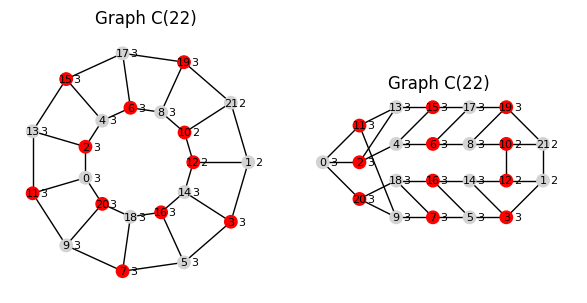

removal of element  2  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


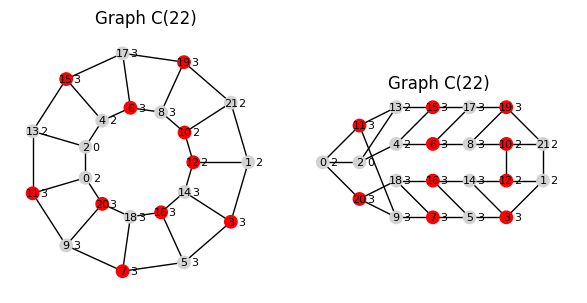

removal of element  3  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


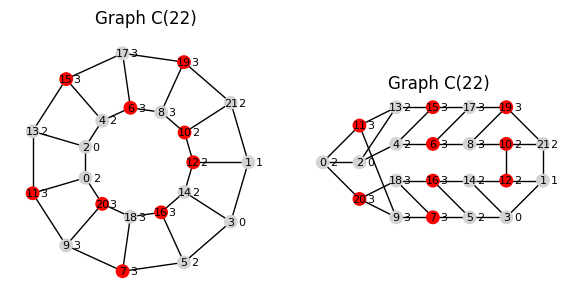

removal of element  6  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


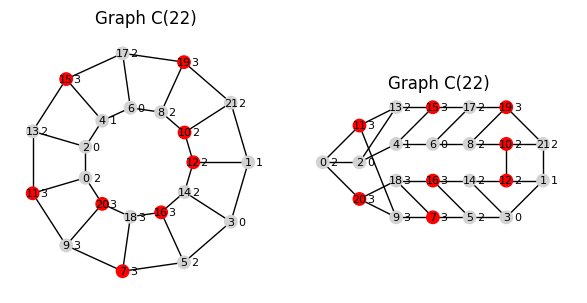

removal of element  7  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


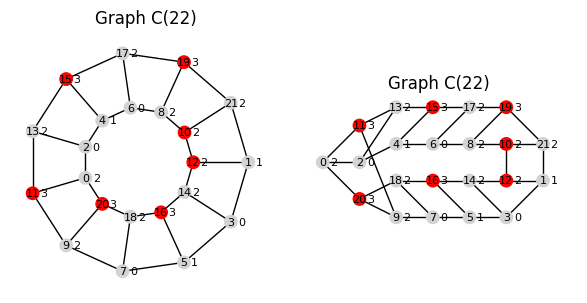

Calculated min infection number: 7


In [20]:
G, n, _ = generate_graphs(22)[1]     # prism
fully_infect(G)

print("Theoretical min infection number: " + str(math.ceil(n/4)+1))

calc_graph_values(G)
display_graph_stage(G, prism=True)

# display_graph_stage(G, prism=True)

# 1. stage
print("initial removal")
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G, prism=True)

for _ in range(5):
    if len(pc) == 0:
        break
    
    e = pc[0]
    print("removal of element ", e, " -> ", G.nodes[pc[0]])
    G.nodes[pc[0]]["infected"] = False
    pc = calc_graph_values(G)
    
    H, infected_nodes, healthy_nodes = fully_endemic(G)
    print("Graph healhy nodes ", healthy_nodes)
    
    display_graph_stage(G, prism=True)


min_infection_number = 0

for i in G.nodes:
    if G.nodes[i].get("infected"):
        min_infection_number += 1

print("Calculated min infection number: " + str(min_infection_number))

number of graphs for n=22 : 2
Theoretical min infection number: 7


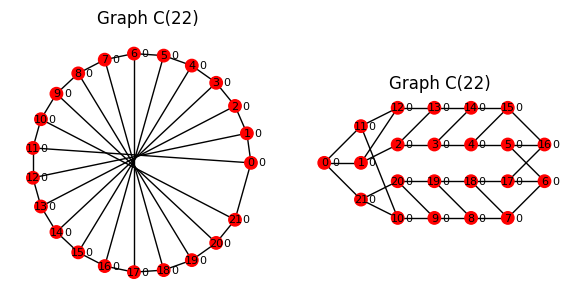

initial removal


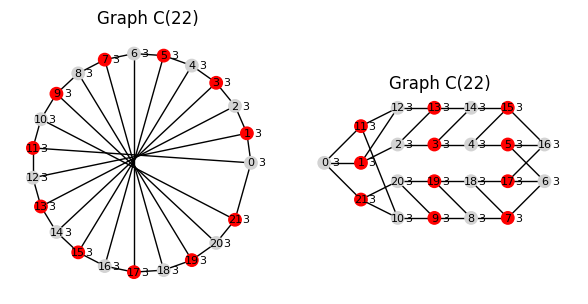

removal of element  1  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


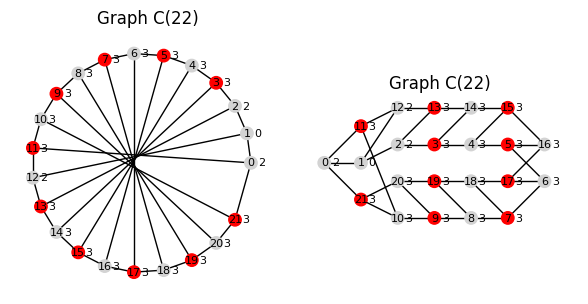

removal of element  3  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


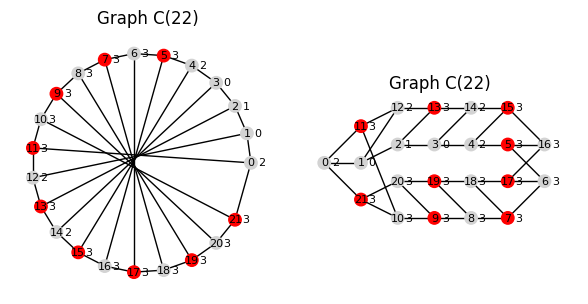

removal of element  5  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


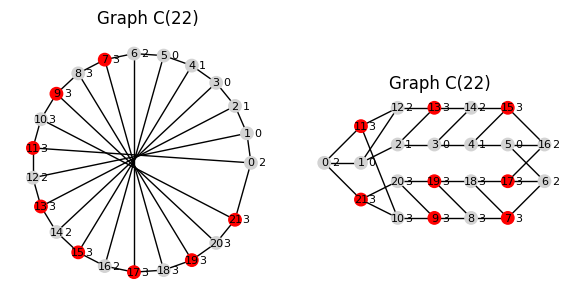

removal of element  7  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


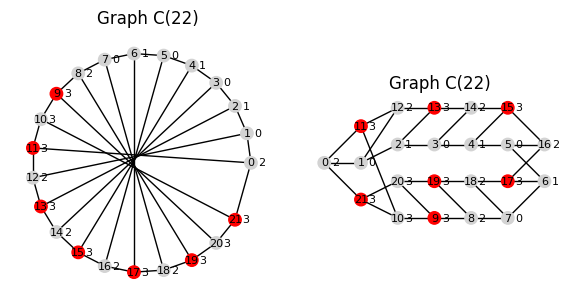

removal of element  9  ->  {'infected': 1, 'infection_influence': 3}
Graph healhy nodes  []


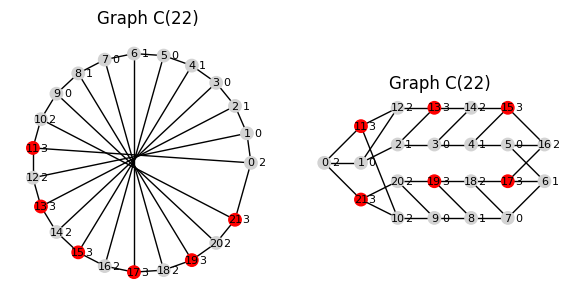

Calculated min infection number: 6


In [21]:
G, n, _ = generate_graphs(22)[0]     # mobius
fully_infect(G)


print("Theoretical min infection number: " + str(math.ceil(n/4)+1))

calc_graph_values(G)
display_graph_stage(G, prism=False)


# 1. stage
print("initial removal")
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G, prism=False)

for _ in range(10):
    if len(pc) == 0:
        break

    e = pc[0]
    print("removal of element ", e, " -> ", G.nodes[pc[0]])
    G.nodes[pc[0]]["infected"] = False
    pc = calc_graph_values(G)
    
    H, infected_nodes, healthy_nodes = fully_endemic(G)
    print("Graph healhy nodes ", healthy_nodes)
    
    display_graph_stage(G, prism=False)



min_infection_number = 0

for i in G.nodes:
    if G.nodes[i].get("infected"):
        min_infection_number += 1

print("Calculated min infection number: " + str(min_infection_number))